<div style="background-color: #1F3864; padding: 20px; border-radius: 5px; margin-bottom: 20px;">
    <h1 style="color: white; margin: 0; font-size: 24px;">13. Cross-Region f(R) Sensitivity Grid</h1>
    <p style="color: #cce0ff; margin: 8px 0 0 0; font-size: 14px;">Applies each region's fitted f(R) curve (donor) to every region's bias-corrected, capped present-day rainfall (recipient), holding each recipient's own rainfall distribution fixed and only varying which damage-function shape translates it into damage... it quantifies how much the damage-amplification estimate would change if a different region's fitted relationship applied. Extrapolation beyond the donor curve's own fitted range is tracked and reported per cell, since applying a foreign curve can require evaluating it outside the range it was validated on.</p>
</div>

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'
REGION_ORDER = ['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']
FR_REGIONS = [r for r in REGION_ORDER if r != 'Indo_Gangetic_Plain']
PRESENT_DAY_WINDOW = 2005

fR_params = pd.read_csv(OUTPUT_DIR + 'fR_fitted_parameters.csv')
fR_input = pd.read_csv(OUTPUT_DIR + 'fR_input_data.csv')

ant_samples = xr.open_dataset(OUTPUT_DIR + 'pr_far_windowed_samples_ant.nc')
nat_samples = xr.open_dataset(OUTPUT_DIR + 'pr_far_windowed_samples_nat.nc')

rx5day_ant_full = xr.open_dataset(OUTPUT_DIR + 'rx5day_ant_regional.nc')

def evaluate_fR(region, R_values, params_df):
    row = params_df[params_df.region == region].iloc[0]
    form = row['form']
    if form == 'linear':
        return row['intercept'] + row['slope'] * R_values
    elif form == 'exponential':
        return row['intercept'] * np.exp(row['slope'] * R_values)
    elif form == 'power':
        return row['intercept'] * np.power(R_values, row['slope'])

# Bias correction + capping for all four regions (FR_REGIONS + IGP)
OVERLAP_YEARS = slice(2000, 2014)
corrected_ant = {}
corrected_nat = {}
capped_ant = {}
capped_nat = {}
bias_records = []

for region in REGION_ORDER:
    region_idx = REGION_ORDER.index(region)

    mpi_overlap = rx5day_ant_full['rx5day_ant_regional'].isel(region=region_idx).sel(year=OVERLAP_YEARS).values.flatten()
    mpi_mean = np.mean(mpi_overlap)
    era5_overlap = fR_input[(fR_input.region == region) & (fR_input.year >= 2000) & (fR_input.year <= 2014)]['rx5day_mm']
    era5_mean = era5_overlap.mean()
    scale = era5_mean / mpi_mean
    bias_records.append({'region': region, 'scale_factor': scale})

    ant_vals = ant_samples['rx5day_ant_windowed'].sel(window_centre_year=PRESENT_DAY_WINDOW, region=region).values
    nat_vals = nat_samples['rx5day_nat_windowed'].sel(window_centre_year=PRESENT_DAY_WINDOW, region=region).values

    corrected_ant[region] = ant_vals * scale
    corrected_nat[region] = nat_vals * scale

    obs = fR_input[fR_input.region == region]['rx5day_mm']
    capped_ant[region] = np.clip(corrected_ant[region], obs.min(), obs.max())
    capped_nat[region] = np.clip(corrected_nat[region], obs.min(), obs.max())

bias_df = pd.DataFrame(bias_records)
print(bias_df.to_string(index=False))
print("\nSetup complete, capped_ant/capped_nat available for all 4 regions")

             region  scale_factor
      Central_India      1.606578
Indo_Gangetic_Plain      1.613539
          Northeast      1.832322
      Western_Ghats      1.839100

Setup complete, capped_ant/capped_nat available for all 4 regions


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 1: 3x4 Sensitivity Grid</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Applies each of the three valid donor f(R) curves (Central India, Northeast, Western Ghats) to each region's own bias-corrected, capped present-day rainfall. Extrapolation beyond the donor curve's own fitted range is tracked per cell.</p>
</div>

In [2]:
DONOR_REGIONS = FR_REGIONS  # Central_India, Northeast, Western_Ghats, valid f(R) curves only
RECIPIENT_REGIONS = REGION_ORDER  # all four, rainfall is valid for any region

sensitivity_records = []

for donor in DONOR_REGIONS:
    donor_obs = fR_input[fR_input.region == donor]['rx5day_mm']
    donor_min, donor_max = donor_obs.min(), donor_obs.max()

    for recipient in RECIPIENT_REGIONS:
        ant_vals_raw = capped_ant[recipient]
        nat_vals_raw = capped_nat[recipient]

        # Track extrapolation BEFORE re-capping to the donor's range
        n_outside = np.sum((ant_vals_raw < donor_min) | (ant_vals_raw > donor_max))
        pct_outside = 100 * n_outside / len(ant_vals_raw)

        # Re-cap recipient's rainfall to the DONOR's own fitted range,
        # so the donor curve is never evaluated outside where it was fitted
        ant_vals_donorcapped = np.clip(ant_vals_raw, donor_min, donor_max)
        nat_vals_donorcapped = np.clip(nat_vals_raw, donor_min, donor_max)

        D_ant = evaluate_fR(donor, ant_vals_donorcapped, fR_params)
        D_nat = evaluate_fR(donor, nat_vals_donorcapped, fR_params)

        E_D_ant = np.mean(D_ant)
        E_D_nat = np.mean(D_nat)
        delta = E_D_ant / E_D_nat

        sensitivity_records.append({
            'donor': donor, 'recipient': recipient,
            'is_own_curve': donor == recipient,
            'delta': delta, 'E_D_ant': E_D_ant, 'E_D_nat': E_D_nat,
            'pct_extrapolated_before_donorcap': pct_outside
        })

sensitivity_df = pd.DataFrame(sensitivity_records)
print(sensitivity_df.to_string(index=False))

        donor           recipient  is_own_curve    delta      E_D_ant      E_D_nat  pct_extrapolated_before_donorcap
Central_India       Central_India          True 1.048110  1788.013560  1705.940746                          0.000000
Central_India Indo_Gangetic_Plain         False 1.060292   887.962336   837.469953                         12.666667
Central_India           Northeast         False 0.992183  3419.701116  3446.645061                         82.000000
Central_India       Western_Ghats         False 1.099336  1170.623010  1064.845087                          4.833333
    Northeast       Central_India         False 1.011476  1687.892574  1668.742390                         73.000000
    Northeast Indo_Gangetic_Plain         False 1.000000  1595.228170  1595.228170                        100.000000
    Northeast           Northeast          True 1.006156  3383.727846  3363.023804                          0.000000
    Northeast       Western_Ghats         False 1.000000  1595.2

In [3]:
sensitivity_df['reliable'] = sensitivity_df['pct_extrapolated_before_donorcap'] < 50
print(sensitivity_df[['donor', 'recipient', 'delta', 'pct_extrapolated_before_donorcap', 'reliable']].to_string(index=False))

        donor           recipient    delta  pct_extrapolated_before_donorcap  reliable
Central_India       Central_India 1.048110                          0.000000      True
Central_India Indo_Gangetic_Plain 1.060292                         12.666667      True
Central_India           Northeast 0.992183                         82.000000     False
Central_India       Western_Ghats 1.099336                          4.833333      True
    Northeast       Central_India 1.011476                         73.000000     False
    Northeast Indo_Gangetic_Plain 1.000000                        100.000000     False
    Northeast           Northeast 1.006156                          0.000000      True
    Northeast       Western_Ghats 1.000000                        100.000000     False
Western_Ghats       Central_India 1.086283                         27.333333      True
Western_Ghats Indo_Gangetic_Plain 1.283229                          0.000000      True
Western_Ghats           Northeast 1.000000 

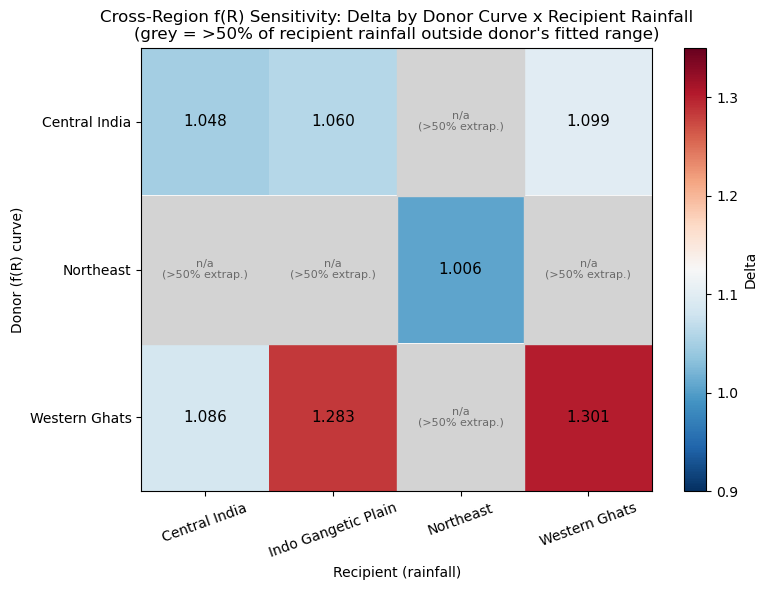

In [4]:
import matplotlib.colors as mcolors

pivot_delta = sensitivity_df.pivot(index='donor', columns='recipient', values='delta')
pivot_reliable = sensitivity_df.pivot(index='donor', columns='recipient', values='reliable')

pivot_delta = pivot_delta.reindex(index=DONOR_REGIONS, columns=REGION_ORDER)
pivot_reliable = pivot_reliable.reindex(index=DONOR_REGIONS, columns=REGION_ORDER)

fig, ax = plt.subplots(figsize=(8, 6))

masked_delta = pivot_delta.where(pivot_reliable)

im = ax.imshow(masked_delta, cmap='RdBu_r', vmin=0.9, vmax=1.35, aspect='auto')

for i, donor in enumerate(DONOR_REGIONS):
    for j, recipient in enumerate(REGION_ORDER):
        reliable = pivot_reliable.loc[donor, recipient]
        val = pivot_delta.loc[donor, recipient]
        if reliable:
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=11)
        else:
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color='lightgrey'))
            ax.text(j, i, 'n/a\n(>50% extrap.)', ha='center', va='center', fontsize=8, color='dimgrey')

ax.set_xticks(range(len(REGION_ORDER)))
ax.set_xticklabels([r.replace('_', ' ') for r in REGION_ORDER], rotation=20)
ax.set_yticks(range(len(DONOR_REGIONS)))
ax.set_yticklabels([r.replace('_', ' ') for r in DONOR_REGIONS])
ax.set_xlabel('Recipient (rainfall)')
ax.set_ylabel('Donor (f(R) curve)')
ax.set_title('Cross-Region f(R) Sensitivity: Delta by Donor Curve x Recipient Rainfall\n(grey = >50% of recipient rainfall outside donor\'s fitted range)')

plt.colorbar(im, ax=ax, label='Delta')
plt.tight_layout()
# Reported in the dissertation as Figure 24
plt.savefig(OUTPUT_DIR + 'figure_fR_sensitivity_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
sensitivity_df.to_csv(OUTPUT_DIR + 'fR_sensitivity_grid_results.csv', index=False)
print(f"Saved: {OUTPUT_DIR}fR_sensitivity_grid_results.csv")
print(f"Rows: {len(sensitivity_df)}")

Saved: /home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/fR_sensitivity_grid_results.csv
Rows: 12


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 2: Visualizing the Curves</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Plots all three donor f(R) curves together, each shown over its own fitted (reliable) rainfall range, with each recipient region's actual present-day rainfall distribution overlaid as a rug/histogram beneath, showing directly how differently each curve would translate a given region's rainfall into damage, and how much of that region's rainfall each foreign curve can plausibly cover.</p>
</div>

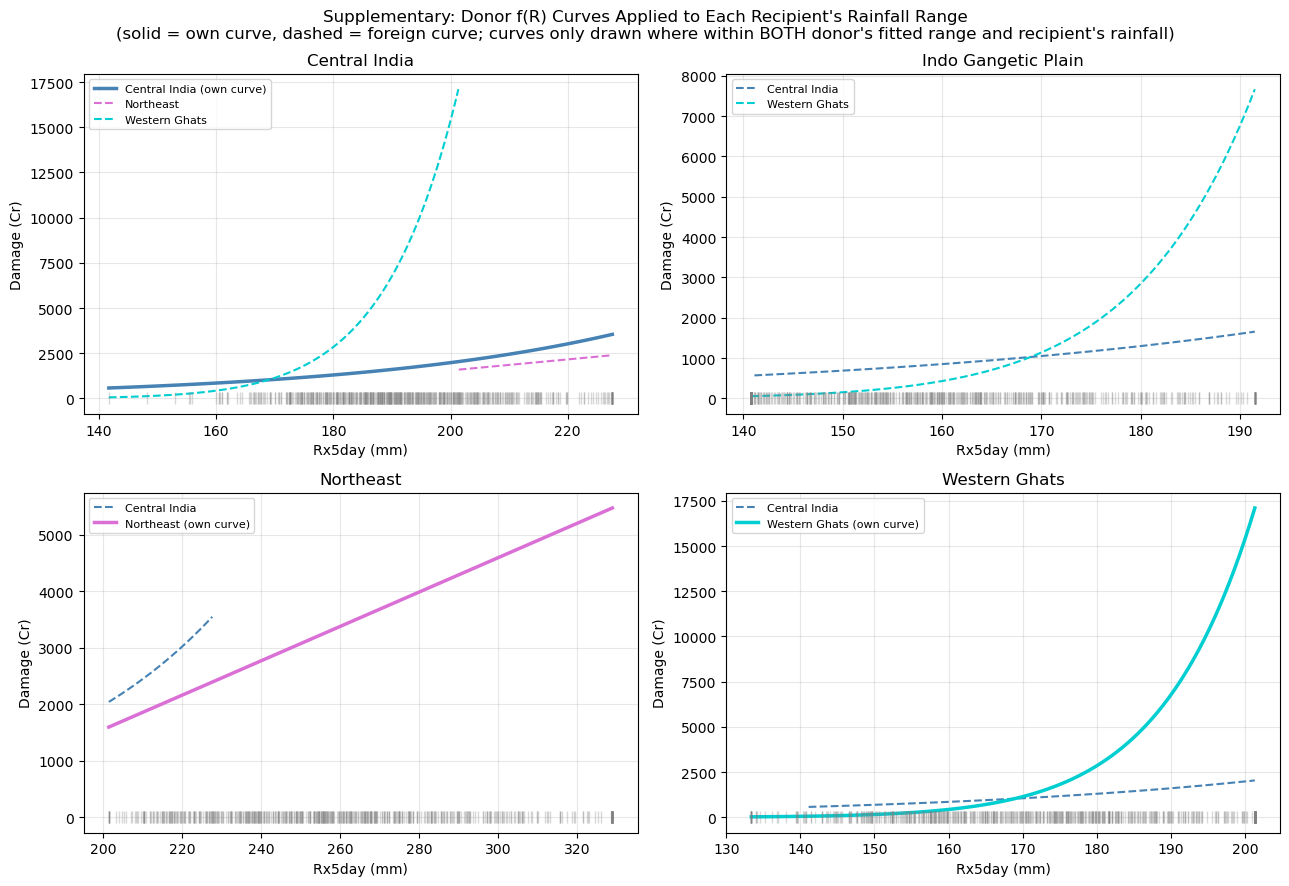

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

donor_colors = {'Central_India': 'steelblue', 'Northeast': 'orchid', 'Western_Ghats': 'darkturquoise'}

for i, recipient in enumerate(REGION_ORDER):
    ax = axes[i]

    recipient_vals = capped_ant[recipient]
    x_min, x_max = recipient_vals.min(), recipient_vals.max()

    for donor in DONOR_REGIONS:
        donor_obs = fR_input[fR_input.region == donor]['rx5day_mm']
        donor_min, donor_max = donor_obs.min(), donor_obs.max()

        plot_min = max(x_min, donor_min)
        plot_max = min(x_max, donor_max)

        if plot_min < plot_max:
            R_range = np.linspace(plot_min, plot_max, 100)
            D_range = evaluate_fR(donor, R_range, fR_params)
            style = '-' if donor == recipient else '--'
            width = 2.5 if donor == recipient else 1.5
            label = f'{donor.replace("_"," ")}{" (own curve)" if donor == recipient else ""}'
            ax.plot(R_range, D_range, style, color=donor_colors[donor], linewidth=width, label=label)

    ax.plot(recipient_vals, np.zeros_like(recipient_vals), '|', color='grey', alpha=0.3, markersize=8)

    ax.set_title(recipient.replace('_', ' '))
    ax.set_xlabel('Rx5day (mm)')
    ax.set_ylabel('Damage (Cr)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Supplementary: Donor f(R) Curves Applied to Each Recipient\'s Rainfall Range\n(solid = own curve, dashed = foreign curve; curves only drawn where within BOTH donor\'s fitted range and recipient\'s rainfall)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'supplementary_fR_curves_by_recipient.png', dpi=150, bbox_inches='tight')
plt.show()